# Factor Exposure Analysis
**Docker image**: `ml4t`

## Purpose
Decompose portfolio risk and return into factor contributions using regression
against the Fama-French factor library, track how those exposures evolve, and
show how attribution becomes ambiguous once factors are correlated.

## Learning Objectives
After completing this notebook, you will be able to:
- Estimate CAPM, Fama-French 3-factor, and Fama-French 5-factor exposures
- Compute rolling factor betas to detect exposure drift through time
- Decompose returns into factor contributions and alpha with HAC standard errors
- Diagnose model misspecification via residual correlation and precision-matrix stability

## Book reference
Chapter 19 §19.2 (risk taxonomy) and §19.5 (decomposing risk); the portfolio
Fama-French regression is the empirical anchor for the §19.5 alpha-vs-beta
discussion.

## Prerequisites
Familiarity with linear regression and the Fama-French factor framework.

## Setup

In [1]:
"""Factor Exposure Analysis — decompose portfolio risk into market, size, value, and other factor components."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import statsmodels.api as sm
from ml4t.data.providers.fama_french import FamaFrenchProvider
from ml4t.diagnostic.evaluation import (
    FactorData,
    compute_factor_model,
    compute_return_attribution,
    compute_risk_attribution,
    compute_rolling_exposures,
)
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA

from data import load_etfs
from utils.reproducibility import set_global_seeds

.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:32: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.

  self.default_format = "png"
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:33: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.

  self.default_width = 700
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:34: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.

  self.default_height = 500
.venv/lib/python3.14/site-packages/kaleido/scopes/plotly.py:35: DeprecationWarning: 
Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be rem

In [3]:
MAX_SYMBOLS = 0
SEED = 42

In [4]:
set_global_seeds(SEED)

## 1. Load Factor Data

Fama-French factors are available from Ken French's data library via FamaFrenchProvider.

In [5]:
# Load Fama-French factors using ml4t-data provider
ff_provider = FamaFrenchProvider()

ff3_pl = ff_provider.fetch("ff3", frequency="daily", start="2010-01-01")
ff3 = ff3_pl.to_pandas()
ff3["timestamp"] = pd.to_datetime(ff3["timestamp"])
ff3 = ff3.set_index("timestamp")

ff5_pl = ff_provider.fetch("ff5", frequency="daily", start="2010-01-01")
ff5 = ff5_pl.to_pandas()
ff5["timestamp"] = pd.to_datetime(ff5["timestamp"])
ff5 = ff5.set_index("timestamp")

print("Fama-French factors loaded via FamaFrenchProvider")
print(f"\n3-Factor columns: {ff3.columns.tolist()}")
print(f"5-Factor columns: {ff5.columns.tolist()}")

2026-06-13 00:19:24 [debug    ] Rate limiter initialized       max_calls=60 period=60.0 provider=fama_french


2026-06-13 00:19:24 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-06-13 00:19:24 [info     ] Initialized Fama-French provider cache_path=data/factors/fama-french name=FamaFrenchProvider use_cache=True


2026-06-13 00:19:24 [debug    ] Loading from cache             file=data/factors/fama-french/ff3_daily.parquet name=FamaFrenchProvider


2026-06-13 00:19:24 [info     ] Fetched Fama-French data       columns=5 dataset=ff3 frequency=daily name=FamaFrenchProvider rows=4063


2026-06-13 00:19:24 [debug    ] Loading from cache             file=data/factors/fama-french/ff5_daily.parquet name=FamaFrenchProvider


2026-06-13 00:19:24 [info     ] Fetched Fama-French data       columns=7 dataset=ff5 frequency=daily name=FamaFrenchProvider rows=4063


Fama-French factors loaded via FamaFrenchProvider

3-Factor columns: ['Mkt-RF', 'SMB', 'HML', 'RF']
5-Factor columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


In [6]:
# Summary statistics
print("\nFactor Summary Statistics (Annualized)")
print("=" * 50)
for col in ["Mkt-RF", "SMB", "HML"]:
    ann_ret = ff3[col].mean() * 252
    ann_vol = ff3[col].std() * np.sqrt(252)
    print(f"{col}: Return={ann_ret * 100:.2f}%, Vol={ann_vol * 100:.1f}%")


Factor Summary Statistics (Annualized)
Mkt-RF: Return=13.32%, Vol=17.8%
SMB: Return=-0.78%, Vol=9.8%
HML: Return=-0.84%, Vol=12.3%


## 2. Load Portfolio Data

In [7]:
# Load from canonical ETF universe
# Using ETFs with different style exposures for factor analysis:
# SPY (market), QQQ (tech/growth), IWM (small cap), VTV (value), VUG (growth)
SYMBOLS = ["SPY", "QQQ", "IWM", "VTV", "VUG"]
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"

etf_data = load_etfs()

# Filter to symbols and date range
etf_filtered = (
    etf_data.filter(pl.col("symbol").is_in(SYMBOLS))
    .filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    .filter(pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
    .sort(["symbol", "timestamp"])
)

# Pivot to wide format for returns calculation
close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .to_pandas()
    .set_index("timestamp")
)
close_prices.index = pd.to_datetime(close_prices.index)
close_prices = close_prices.ffill().dropna()

returns = close_prices.pct_change().dropna()

available_symbols = [symbol for symbol in SYMBOLS if symbol in returns.columns]
missing_symbols = sorted(set(SYMBOLS) - set(available_symbols))
if missing_symbols:
    print(f"Missing symbols in canonical data: {missing_symbols}")
if not available_symbols:
    raise ValueError("No requested symbols available in canonical ETF data")
SYMBOLS = available_symbols

print(f"Loaded {len(returns):,} daily returns for {len(SYMBOLS)} assets from canonical data")

# Align with factor data
common_dates = returns.index.intersection(ff3.index)
returns = returns.loc[common_dates]
ff3_aligned = ff3.loc[common_dates]
ff5_aligned = ff5.loc[common_dates]

print(f"Aligned data: {len(common_dates):,} days")

Loaded 3,521 daily returns for 5 assets from canonical data
Aligned data: 3,521 days


## 3. CAPM (Single-Factor) Analysis

$R_i - R_f = \alpha + \beta (R_m - R_f) + \epsilon$

In [8]:
def capm_regression(
    returns: pd.Series,
    market_excess: pd.Series,
    rf: pd.Series,
) -> dict:
    """
    Run CAPM regression.

    Returns:
        Dictionary with alpha, beta, R-squared, t-stats
    """
    # Excess returns - reset indices for statsmodels alignment
    excess_returns = (returns - rf).reset_index(drop=True)

    # Regression with Newey-West HAC standard errors (maxlags=5 for daily series).
    # Coefficients are unchanged from OLS; only the standard errors / t-stats /
    # confidence intervals incorporate residual autocorrelation and
    # heteroscedasticity, which OLS understates on daily return regressions.
    X = sm.add_constant(market_excess.reset_index(drop=True))
    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    return {
        "alpha": model.params.iloc[0],
        "alpha_annual": model.params.iloc[0] * 252,
        "alpha_tstat": model.tvalues.iloc[0],
        "beta": model.params.iloc[1],
        "beta_tstat": model.tvalues.iloc[1],
        "r_squared": model.rsquared,
        "resid_std": model.resid.std(),
    }

In [9]:
# CAPM analysis for each asset
print("CAPM Analysis")
print("=" * 70)

capm_results = {}
for symbol in SYMBOLS:
    result = capm_regression(returns[symbol], ff3_aligned["Mkt-RF"], ff3_aligned["RF"])
    capm_results[symbol] = result

    print(f"\n{symbol}:")
    print(f"  Alpha:    {result['alpha_annual'] * 100:+.2f}% (t={result['alpha_tstat']:.2f})")
    print(f"  Beta:     {result['beta']:.3f} (t={result['beta_tstat']:.2f})")
    print(f"  R²:       {result['r_squared']:.3f}")

CAPM Analysis

SPY:
  Alpha:    +0.37% (t=0.90)
  Beta:     0.959 (t=303.56)
  R²:       0.990

QQQ:
  Alpha:    +3.93% (t=2.03)
  Beta:     1.069 (t=62.69)
  R²:       0.870

IWM:
  Alpha:    -3.59% (t=-1.62)
  Beta:     1.144 (t=67.73)
  R²:       0.845

VTV:
  Alpha:    -0.32% (t=-0.22)
  Beta:     0.890 (t=60.95)
  R²:       0.894

VUG:
  Alpha:    +1.10% (t=0.84)
  Beta:     1.050 (t=97.81)
  R²:       0.935


.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(
.venv/lib/python3.14/site-packages/kaleido/scopes/base.py:188: DeprecationWarning: setDaemon() is deprecated, set the daemon attribute instead
  self._std_error_thread.setDaemon(True)


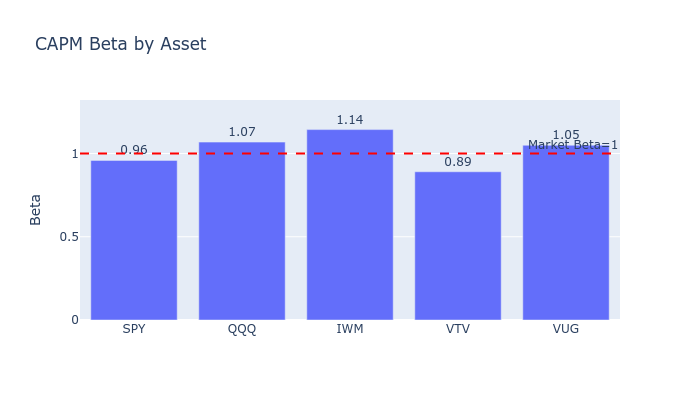

In [10]:
# Visualize CAPM betas
fig = go.Figure(
    data=[
        go.Bar(
            x=list(capm_results.keys()),
            y=[r["beta"] for r in capm_results.values()],
            text=[f"{r['beta']:.2f}" for r in capm_results.values()],
            textposition="outside",
        )
    ]
)

fig.add_hline(y=1, line_dash="dash", line_color="red", annotation_text="Market Beta=1")

fig.update_layout(
    title="CAPM Beta by Asset",
    yaxis_title="Beta",
    height=400,
)
fig.show()

## 4. Fama-French 3-Factor Analysis

$R_i - R_f = \alpha + \beta_{MKT}(R_m - R_f) + \beta_{SMB}(SMB) + \beta_{HML}(HML) + \epsilon$

- **MKT**: Market excess return
- **SMB**: Small Minus Big (size factor)
- **HML**: High Minus Low (value factor)

In [11]:
def ff3_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> dict:
    """
    Run Fama-French 3-factor regression.
    """
    # Excess returns - reset indices for statsmodels alignment
    excess_returns = (returns - factors["RF"]).reset_index(drop=True)

    # Factor matrix
    X = factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True)
    X = sm.add_constant(X)

    # Newey-West HAC standard errors with maxlags=5 for daily return series.
    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    return {
        "alpha": model.params["const"],
        "alpha_annual": model.params["const"] * 252,
        "alpha_tstat": model.tvalues["const"],
        "beta_mkt": model.params["Mkt-RF"],
        "beta_smb": model.params["SMB"],
        "beta_hml": model.params["HML"],
        "r_squared": model.rsquared,
        "tstats": dict(model.tvalues),
    }

In [12]:
# FF3 analysis for each asset
print("Fama-French 3-Factor Analysis")
print("=" * 70)

ff3_results = {}
for symbol in SYMBOLS:
    result = ff3_regression(returns[symbol], ff3_aligned)
    ff3_results[symbol] = result

    print(f"\n{symbol}:")
    print(f"  Alpha:    {result['alpha_annual'] * 100:+.2f}% (t={result['alpha_tstat']:.2f})")
    print(f"  Mkt-RF:   {result['beta_mkt']:.3f}")
    print(f"  SMB:      {result['beta_smb']:.3f}")
    print(f"  HML:      {result['beta_hml']:.3f}")
    print(f"  R²:       {result['r_squared']:.3f}")

Fama-French 3-Factor Analysis

SPY:
  Alpha:    +0.16% (t=0.63)
  Mkt-RF:   0.978
  SMB:      -0.131
  HML:      0.020
  R²:       0.995

QQQ:
  Alpha:    +3.04% (t=2.22)
  Mkt-RF:   1.091
  SMB:      -0.110
  HML:      -0.418
  R²:       0.936

IWM:
  Alpha:    -1.64% (t=-2.56)
  Mkt-RF:   1.015
  SMB:      0.862
  HML:      0.220
  R²:       0.985

VTV:
  Alpha:    +0.02% (t=0.02)
  Mkt-RF:   0.903
  SMB:      -0.124
  HML:      0.344
  R²:       0.963

VUG:
  Alpha:    +0.40% (t=0.55)
  Mkt-RF:   1.067
  SMB:      -0.091
  HML:      -0.317
  R²:       0.977


.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


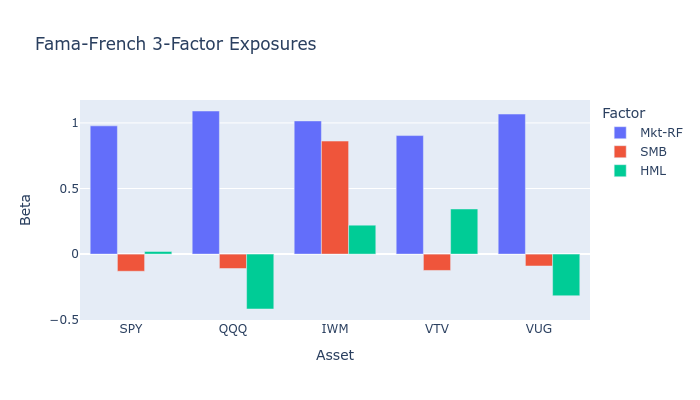

In [13]:
# Visualize factor exposures
factor_exposure_df = pd.DataFrame(
    {
        symbol: {"Mkt-RF": result["beta_mkt"], "SMB": result["beta_smb"], "HML": result["beta_hml"]}
        for symbol, result in ff3_results.items()
    }
).T

fig = px.bar(
    factor_exposure_df.reset_index().melt(id_vars="index"),
    x="index",
    y="value",
    color="variable",
    barmode="group",
    title="Fama-French 3-Factor Exposures",
    labels={"index": "Asset", "value": "Beta", "variable": "Factor"},
)
fig.update_layout(height=400)
fig.show()

## 5. Fama-French 5-Factor Analysis

Adds two more factors:
- **RMW**: Robust Minus Weak (profitability)
- **CMA**: Conservative Minus Aggressive (investment)

In [14]:
def ff5_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> dict:
    """
    Run Fama-French 5-factor regression.
    """
    # Reset indices for statsmodels alignment
    excess_returns = (returns - factors["RF"]).reset_index(drop=True)

    X = factors[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True)
    X = sm.add_constant(X)

    # Newey-West HAC (maxlags=5) for the daily series.
    model = sm.OLS(excess_returns, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    return {
        "alpha": model.params["const"],
        "alpha_annual": model.params["const"] * 252,
        "alpha_tstat": model.tvalues["const"],
        "betas": {col: model.params[col] for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]},
        "r_squared": model.rsquared,
        "tstats": dict(model.tvalues),
    }

In [15]:
# FF5 analysis
print("Fama-French 5-Factor Analysis")
print("=" * 70)

ff5_results = {}
for symbol in SYMBOLS:
    result = ff5_regression(returns[symbol], ff5_aligned)
    ff5_results[symbol] = result

    print(f"\n{symbol}:")
    print(f"  Alpha:   {result['alpha_annual'] * 100:+.2f}% (t={result['alpha_tstat']:.2f})")
    for factor, beta in result["betas"].items():
        print(f"  {factor:7s}: {beta:+.3f}")
    print(f"  R²:      {result['r_squared']:.3f}")

Fama-French 5-Factor Analysis

SPY:
  Alpha:   -0.13% (t=-0.56)
  Mkt-RF : +0.984
  SMB    : -0.113
  HML    : +0.026
  RMW    : +0.057
  CMA    : +0.026
  R²:      0.996

QQQ:
  Alpha:   +3.21% (t=2.44)
  Mkt-RF : +1.079
  SMB    : -0.111
  HML    : -0.321
  RMW    : +0.100
  CMA    : -0.271
  R²:      0.942

IWM:
  Alpha:   -1.36% (t=-2.52)
  Mkt-RF : +1.008
  SMB    : +0.845
  HML    : +0.066
  RMW    : -0.083
  CMA    : +0.009
  R²:      0.987

VTV:
  Alpha:   -0.51% (t=-0.62)
  Mkt-RF : +0.919
  SMB    : -0.089
  HML    : +0.293
  RMW    : +0.029
  CMA    : +0.195
  R²:      0.965

VUG:
  Alpha:   +0.62% (t=0.89)
  Mkt-RF : +1.059
  SMB    : -0.102
  HML    : -0.246
  RMW    : +0.037
  CMA    : -0.171
  R²:      0.979


.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


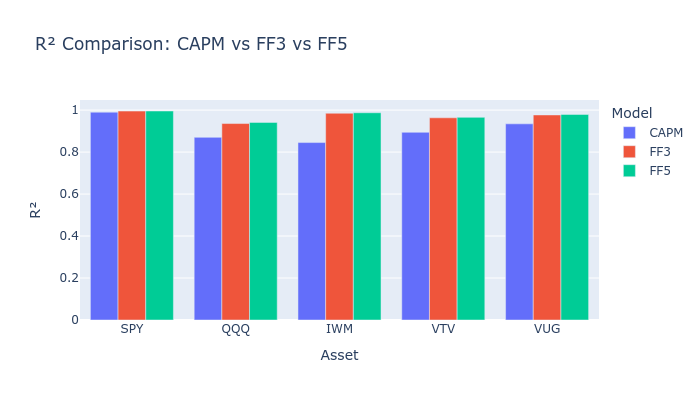

In [16]:
# Compare R² across models
r2_comparison = pd.DataFrame(
    {
        symbol: {
            "CAPM": capm_results[symbol]["r_squared"],
            "FF3": ff3_results[symbol]["r_squared"],
            "FF5": ff5_results[symbol]["r_squared"],
        }
        for symbol in SYMBOLS
    }
).T

fig = px.bar(
    r2_comparison.reset_index().melt(id_vars="index"),
    x="index",
    y="value",
    color="variable",
    barmode="group",
    title="R² Comparison: CAPM vs FF3 vs FF5",
    labels={"index": "Asset", "value": "R²", "variable": "Model"},
)
fig.update_layout(height=400)
fig.show()

## 6. Rolling Factor Exposures

Factor betas change over time. Rolling analysis reveals dynamics.

In [17]:
def rolling_factor_regression(
    returns: pd.Series,
    factors: pd.DataFrame,
    window: int = 252,
) -> pd.DataFrame:
    """
    Calculate rolling factor exposures.
    """
    results = []

    for i in range(window, len(returns)):
        window_returns = returns.iloc[i - window : i]
        window_factors = factors.iloc[i - window : i]

        excess_returns = (window_returns - window_factors["RF"]).reset_index(drop=True)
        X = sm.add_constant(window_factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True))

        model = sm.OLS(excess_returns, X).fit()
        results.append(
            {
                "timestamp": returns.index[i],
                "alpha": model.params["const"] * 252,
                "beta_mkt": model.params["Mkt-RF"],
                "beta_smb": model.params["SMB"],
                "beta_hml": model.params["HML"],
            }
        )

    return pd.DataFrame(results).set_index("timestamp")

In [18]:
# Rolling analysis for IWM (small cap ETF)
rolling_symbol = "IWM" if "IWM" in SYMBOLS else SYMBOLS[0]
rolling_iwm = rolling_factor_regression(returns[rolling_symbol], ff3_aligned)

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


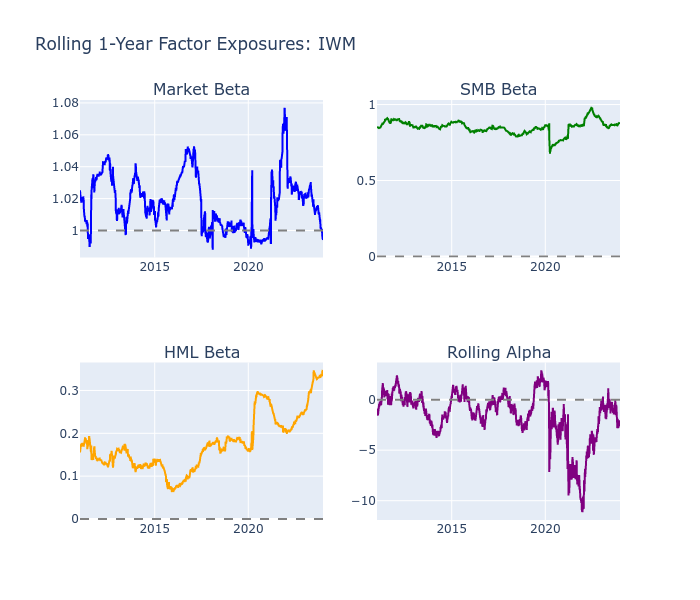

In [19]:
# Visualize rolling factor exposures
fig = make_subplots(
    rows=2, cols=2, subplot_titles=["Market Beta", "SMB Beta", "HML Beta", "Rolling Alpha"]
)

fig.add_trace(
    go.Scatter(x=rolling_iwm.index, y=rolling_iwm["beta_mkt"], name="Mkt", line=dict(color="blue")),
    row=1,
    col=1,
)
fig.add_hline(y=1, line_dash="dash", line_color="gray", row=1, col=1)

fig.add_trace(
    go.Scatter(
        x=rolling_iwm.index, y=rolling_iwm["beta_smb"], name="SMB", line=dict(color="green")
    ),
    row=1,
    col=2,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=1, col=2)

fig.add_trace(
    go.Scatter(
        x=rolling_iwm.index, y=rolling_iwm["beta_hml"], name="HML", line=dict(color="orange")
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=1)

fig.add_trace(
    go.Scatter(
        x=rolling_iwm.index, y=rolling_iwm["alpha"] * 100, name="Alpha", line=dict(color="purple")
    ),
    row=2,
    col=2,
)
fig.add_hline(y=0, line_dash="dash", line_color="gray", row=2, col=2)

fig.update_layout(
    title=f"Rolling 1-Year Factor Exposures: {rolling_symbol}",
    height=600,
    showlegend=False,
)
fig.show()

## 7. Factor Attribution

Decompose portfolio returns into factor contributions.

> **Caveat — contemporaneous full-sample betas.** The helper below fits
> $\beta$ on the entire sample and applies the same $\beta$ at every
> date. This is fine for *teaching* the additive decomposition
> $r_t = \alpha + \beta_{\text{mkt}} f_{\text{mkt},t} + \dots + \varepsilon_t$,
> but it is **not deployable**: future betas leak into past attribution,
> which inflates apparent factor explanation. The deployable counterpart
> — `compute_return_attribution` with rolling/lagged betas — appears in
> §13's library-API walk-through.

In [20]:
def factor_attribution(
    returns: pd.Series,
    factors: pd.DataFrame,
) -> pd.DataFrame:
    """
    Decompose returns into factor contributions.

    Returns DataFrame with daily attribution.
    """
    # Run regression to get betas - reset indices for statsmodels alignment.
    # HAC SE with maxlags=5 for the daily series; coefficients (the betas used
    # for attribution) are unchanged from OLS.
    excess_returns = returns - factors["RF"]
    excess_returns_reset = excess_returns.reset_index(drop=True)
    X = sm.add_constant(factors[["Mkt-RF", "SMB", "HML"]].reset_index(drop=True))
    model = sm.OLS(excess_returns_reset, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

    # Attribution
    alpha_daily = model.params["const"]

    attribution = pd.DataFrame(
        {
            "Total Return": excess_returns,
            "Alpha": alpha_daily,
            "Mkt Contribution": model.params["Mkt-RF"] * factors["Mkt-RF"],
            "SMB Contribution": model.params["SMB"] * factors["SMB"],
            "HML Contribution": model.params["HML"] * factors["HML"],
            "Residual": model.resid.values,
        },
        index=returns.index,
    )

    return attribution

In [21]:
# Attribution for SPY
attribution_symbol = "SPY" if "SPY" in SYMBOLS else SYMBOLS[0]
attribution_spy = factor_attribution(returns[attribution_symbol], ff3_aligned)

# Cumulative attribution
cum_attribution = (1 + attribution_spy).cumprod() - 1

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


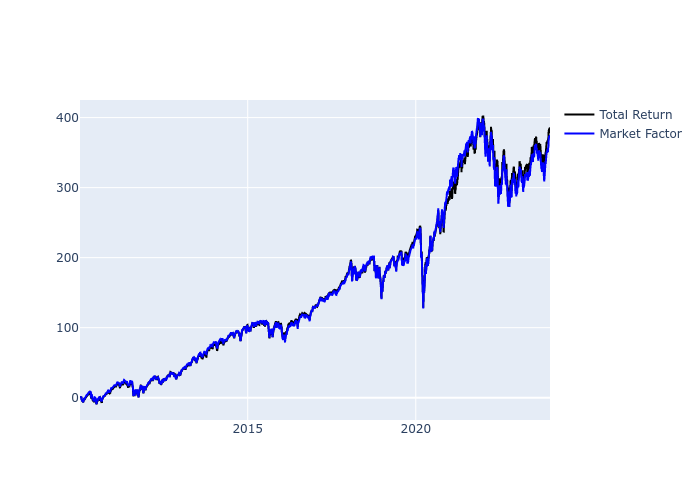

In [22]:
# Visualize cumulative factor attribution
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["Total Return"] * 100,
        name="Total Return",
        line=dict(color="black", width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["Mkt Contribution"] * 100,
        name="Market Factor",
        line=dict(color="blue"),
    )
)

.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


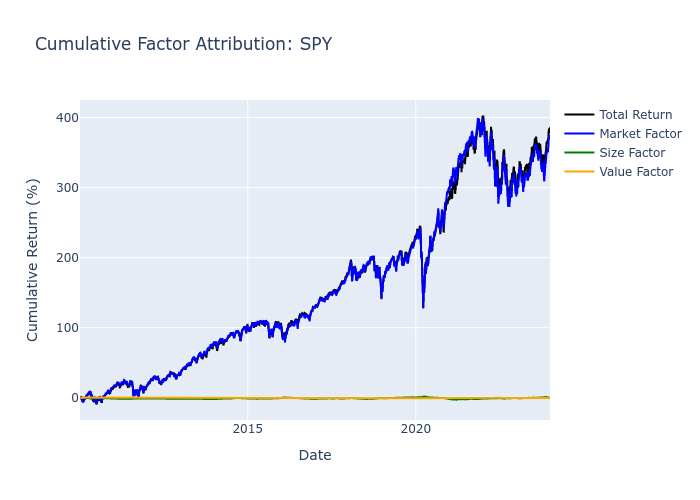

In [23]:
# Add size and value factor contributions
fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["SMB Contribution"] * 100,
        name="Size Factor",
        line=dict(color="green"),
    )
)

fig.add_trace(
    go.Scatter(
        x=cum_attribution.index,
        y=cum_attribution["HML Contribution"] * 100,
        name="Value Factor",
        line=dict(color="orange"),
    )
)

fig.update_layout(
    title=f"Cumulative Factor Attribution: {attribution_symbol}",
    xaxis_title="Date",
    yaxis_title="Cumulative Return (%)",
    height=500,
)
fig.show()

In [24]:
# Summary attribution (annualized)
annual_attribution = attribution_spy.mean() * 252 * 100
print(f"\nAnnualized Factor Attribution: {attribution_symbol}")
print("=" * 40)
for col, value in annual_attribution.items():
    print(f"{col:20s}: {value:+.2f}%")


Annualized Factor Attribution: SPY
Total Return        : +12.80%
Alpha               : +0.16%
Mkt Contribution    : +12.67%
SMB Contribution    : -0.01%
HML Contribution    : -0.03%
Residual            : -0.00%


## 8. Portfolio Factor Exposure

Analyze factor exposure of a multi-asset portfolio.

In [25]:
# Define portfolio
portfolio_weights = {
    "SPY": 0.40,
    "QQQ": 0.20,
    "IWM": 0.15,
    "VTV": 0.15,
    "VUG": 0.10,
}
portfolio_weights = {symbol: portfolio_weights[symbol] for symbol in SYMBOLS}
weight_sum = sum(portfolio_weights.values())
portfolio_weights = {symbol: weight / weight_sum for symbol, weight in portfolio_weights.items()}
if missing_symbols:
    print(f"Portfolio weights renormalized after dropping missing symbols: {missing_symbols}")

# Calculate portfolio returns
portfolio_returns = (returns * pd.Series(portfolio_weights)).sum(axis=1)

# Factor analysis
portfolio_ff3 = ff3_regression(portfolio_returns, ff3_aligned)

print("Portfolio Factor Analysis")
print("=" * 50)
print("\nPortfolio Composition:")
for symbol, weight in portfolio_weights.items():
    print(f"  {symbol}: {weight:.0%}")

print("\nFama-French 3-Factor Results:")
print(f"  Alpha (ann.): {portfolio_ff3['alpha_annual'] * 100:+.2f}%")
print(
    f"  Mkt-RF Beta:  {portfolio_ff3['betas']['Mkt-RF'] if 'betas' in portfolio_ff3 else portfolio_ff3.get('beta_mkt', 0):.3f}"
)
print(
    f"  SMB Beta:     {portfolio_ff3['betas']['SMB'] if 'betas' in portfolio_ff3 else portfolio_ff3.get('beta_smb', 0):.3f}"
)
print(
    f"  HML Beta:     {portfolio_ff3['betas']['HML'] if 'betas' in portfolio_ff3 else portfolio_ff3.get('beta_hml', 0):.3f}"
)
print(f"  R²:           {portfolio_ff3['r_squared']:.3f}")

Portfolio Factor Analysis

Portfolio Composition:
  SPY: 40%
  QQQ: 20%
  IWM: 15%
  VTV: 15%
  VUG: 10%

Fama-French 3-Factor Results:
  Alpha (ann.): +0.47%
  Mkt-RF Beta:  1.004
  SMB Beta:     0.027
  HML Beta:     -0.023
  R²:           0.995


In [26]:
# Compare regressed portfolio betas with weighted-average component betas
weighted_mkt = sum(portfolio_weights[s] * ff3_results[s]["beta_mkt"] for s in SYMBOLS)
weighted_smb = sum(portfolio_weights[s] * ff3_results[s]["beta_smb"] for s in SYMBOLS)
weighted_hml = sum(portfolio_weights[s] * ff3_results[s]["beta_hml"] for s in SYMBOLS)

beta_decomp_df = pd.DataFrame(
    {
        "Portfolio": [
            portfolio_ff3.get("beta_mkt", 0),
            portfolio_ff3.get("beta_smb", 0),
            portfolio_ff3.get("beta_hml", 0),
        ],
        "Weighted Avg": [weighted_mkt, weighted_smb, weighted_hml],
    },
    index=["Mkt-RF", "SMB", "HML"],
).round(3)
beta_decomp_df

,Portfolio,Weighted Avg
Mkt-RF,1.004,1.004
SMB,0.027,0.027
HML,-0.023,-0.023


## 9. Attribution Uncertainty

Point estimates of factor PnL contributions can be misleading when standard
errors are large. When the confidence interval spans zero, the attribution
is uninformative — we cannot distinguish the factor's contribution from noise.

In [27]:
# Compute attribution with standard errors using FF5 for richer example
excess_returns_port = (portfolio_returns - ff5_aligned["RF"]).reset_index(drop=True)
X_ff5 = sm.add_constant(ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True))
# HAC SE (maxlags=5) on the daily FF5 regression — widens CIs vs OLS and may
# flip the spans_zero flag for factors whose CI sits near zero under OLS.
model_ff5 = sm.OLS(excess_returns_port, X_ff5).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

# Factor PnL contribution = beta × factor mean × 252
factor_means = ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].mean()
factor_names_ff5 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

attr_rows = []
for f in factor_names_ff5:
    beta = model_ff5.params[f]
    se_beta = model_ff5.bse[f]
    contrib = beta * factor_means[f] * 252 * 100
    se_contrib = se_beta * abs(factor_means[f]) * 252 * 100
    ci_lo = contrib - 1.96 * se_contrib
    ci_hi = contrib + 1.96 * se_contrib
    attr_rows.append(
        {
            "factor": f,
            "contribution_pct": contrib,
            "se_pct": se_contrib,
            "ci_low_pct": ci_lo,
            "ci_high_pct": ci_hi,
            "spans_zero": ci_lo <= 0 <= ci_hi,
        }
    )

attribution_ci_df = pd.DataFrame(attr_rows).round(4)
attribution_ci_df

,factor,contribution_pct,se_pct,ci_low_pct,ci_high_pct,spans_zero
0,Mkt-RF,13.0223,0.0419,12.9402,13.1045,False
1,SMB,-0.0053,0.0006,-0.0065,-0.0041,False
2,HML,0.0361,0.0067,0.0229,0.0493,False
3,RMW,0.1156,0.0124,0.0912,0.1399,False
4,CMA,-0.0221,0.0055,-0.0329,-0.0113,False


Factors where the 95% confidence interval spans zero (`spans_zero=True`)
provide no reliable attribution signal. Over-interpreting these coefficients
leads to false narratives about portfolio performance drivers.

## 10. Residual Clustering Diagnostic

If idiosyncratic residuals from the factor model are correlated, the model
is missing latent sub-factors. We flag pairs where $|\rho_{ij}| > 0.15$.

In [28]:
# Compute FF5 residuals for each asset
residuals = {}
for symbol in SYMBOLS:
    excess_ret = (returns[symbol] - ff5_aligned["RF"]).reset_index(drop=True)
    X_reset = sm.add_constant(
        ff5_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]].reset_index(drop=True)
    )
    m = sm.OLS(excess_ret, X_reset).fit()
    residuals[symbol] = m.resid.values

resid_df = pd.DataFrame(residuals)
resid_corr = resid_df.corr()

# Flag high residual correlations
THRESHOLD = 0.15
flagged_pairs = []
for i, s1 in enumerate(SYMBOLS):
    for s2 in SYMBOLS[i + 1 :]:
        rho = resid_corr.loc[s1, s2]
        if abs(rho) > THRESHOLD:
            flagged_pairs.append((s1, s2, rho))

print("Residual Correlation Diagnostic")
print("=" * 50)
if flagged_pairs:
    print(f"Pairs exceeding |ρ| > {THRESHOLD}:")
    for s1, s2, rho in sorted(flagged_pairs, key=lambda x: -abs(x[2])):
        print(f"  {s1}-{s2}: ρ = {rho:+.3f}")
else:
    print("No residual pairs exceed threshold — factor model is well-specified.")

Residual Correlation Diagnostic
Pairs exceeding |ρ| > 0.15:
  VTV-VUG: ρ = -0.730
  QQQ-VUG: ρ = +0.536
  QQQ-VTV: ρ = -0.505
  SPY-VTV: ρ = +0.368
  IWM-VTV: ρ = +0.189
  SPY-IWM: ρ = +0.153


.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


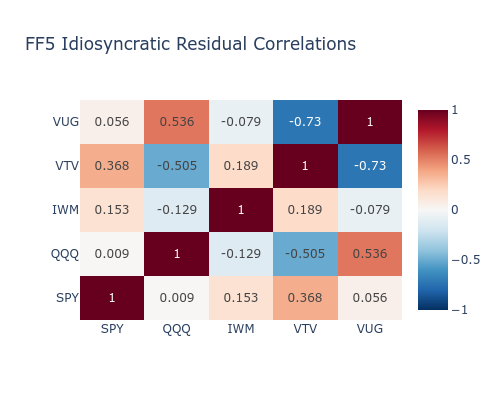

In [29]:
# Heatmap of residual correlations
fig = go.Figure(
    data=go.Heatmap(
        z=resid_corr.values,
        x=SYMBOLS,
        y=SYMBOLS,
        colorscale="RdBu_r",
        zmid=0,
        text=resid_corr.round(3).values,
        texttemplate="%{text}",
    )
)
fig.update_layout(title="FF5 Idiosyncratic Residual Correlations", height=400, width=500)
fig.show()

The strongest residual correlations are VTV–VUG at $-0.730$ and QQQ–VUG
at $+0.536$ — value and growth ETFs share idiosyncratic variation that
the five-factor model does not absorb. These unmodeled correlations
signal latent sub-factors (e.g., sector momentum, crowding) and cause
portfolio risk to be under-estimated when the residuals are treated as
independent.

## 11. Mahalanobis Distance Precision-Matrix Diagnostic

Project each daily return vector through the inverse covariance and track
how erratic the squared distance becomes. A well-conditioned precision
matrix produces $d_t^2$ values clustered near $E[d_t^2] = K$ for $K$
assets; a poorly conditioned one produces large spikes and a high
$\operatorname{Var}(d_t^2)$, signalling unstable covariance estimates and
erratic portfolio-optimizer weights.

$$d_t^2 = \mathbf{r}_t^{\top} \hat{\Omega}^{-1} \mathbf{r}_t,
  \qquad \text{HIGH flag if } \operatorname{Var}(d_t^2) > 2K.$$

In [30]:
# Compute rolling Mahalanobis distance using 63-day covariance
window_cov = 63
ret_matrix = returns[SYMBOLS].values
d2_series = []

for i in range(window_cov, len(ret_matrix)):
    cov_est = np.cov(ret_matrix[i - window_cov : i], rowvar=False)
    try:
        precision = np.linalg.inv(cov_est)
        r_t = ret_matrix[i]
        d2 = r_t @ precision @ r_t
        d2_series.append(d2)
    except np.linalg.LinAlgError:
        d2_series.append(np.nan)

d2_arr = np.array(d2_series)
var_d2 = np.nanvar(d2_arr)

print("MALV Diagnostic")
print("=" * 50)
print(f"Mean d²:  {np.nanmean(d2_arr):.2f} (expected ≈ {len(SYMBOLS)} under Gaussian)")
print(f"Var(d²):  {var_d2:.2f}")
print(
    f"Diagnostic flag: {'HIGH — unstable precision matrix' if var_d2 > 2 * len(SYMBOLS) else 'Acceptable'}"
)

MALV Diagnostic
Mean d²:  6.88 (expected ≈ 5 under Gaussian)
Var(d²):  1457.06
Diagnostic flag: HIGH — unstable precision matrix


.venv/lib/python3.14/site-packages/plotly/io/_base_renderers.py:123: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  image_bytes = to_image(


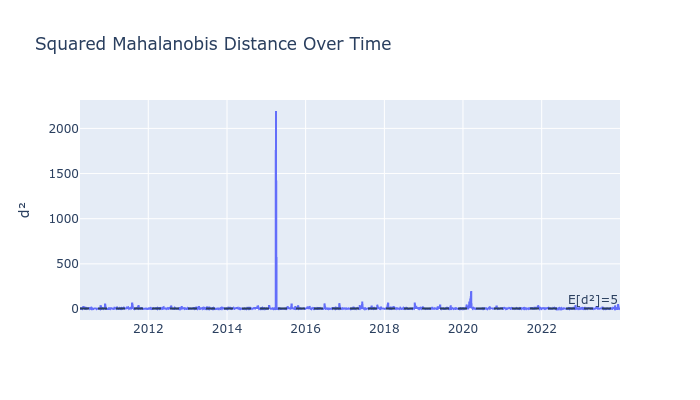

In [31]:
# Plot d² over time
d2_dates = returns.index[window_cov:]
fig = go.Figure()
fig.add_trace(go.Scatter(x=d2_dates, y=d2_arr, mode="lines", name="d²"))
fig.add_hline(y=len(SYMBOLS), line_dash="dash", annotation_text=f"E[d²]={len(SYMBOLS)}")
fig.update_layout(title="Squared Mahalanobis Distance Over Time", yaxis_title="d²", height=400)
fig.show()

On this five-ETF basket the mean $d_t^2 \approx 6.88$ is only slightly
above the Gaussian expectation of 5, but $\operatorname{Var}(d_t^2)
\approx 1457$ blows past the $2K = 10$ threshold and the diagnostic
flags HIGH. Persistently high variance indicates the covariance
estimator is poorly conditioned — a signal to use shrinkage or robust
estimators before feeding into portfolio optimization.

## 12. Factor Rotation and Attribution Ambiguity

When factors are correlated, attribution is not unique — rotating the factor
basis changes factor contributions without changing the portfolio. This demo
applies PCA rotation to FF3 factors and compares attribution before and after.

In [32]:
# PCA rotation of FF3 factors
ff3_factors = ff3_aligned[["Mkt-RF", "SMB", "HML"]].values
pca = PCA(n_components=3)
rotated_factors = pca.fit_transform(ff3_factors)

# Run attribution with original and rotated factors
excess_port = (portfolio_returns - ff3_aligned["RF"]).reset_index(drop=True)

# Original attribution
X_orig = sm.add_constant(pd.DataFrame(ff3_factors, columns=["Mkt-RF", "SMB", "HML"]))
model_orig = sm.OLS(excess_port, X_orig).fit()

# Rotated attribution
X_rot = sm.add_constant(pd.DataFrame(rotated_factors, columns=["PC1", "PC2", "PC3"]))
model_rot = sm.OLS(excess_port, X_rot).fit()

orig_rows = [
    {
        "basis": "Original",
        "factor": f,
        "beta": model_orig.params[f],
        "contribution_pct": model_orig.params[f] * ff3_aligned[f].mean() * 252 * 100,
    }
    for f in ["Mkt-RF", "SMB", "HML"]
]
rot_rows = [
    {
        "basis": "Rotated",
        "factor": pc,
        "beta": model_rot.params[pc],
        "contribution_pct": model_rot.params[pc] * rotated_factors[:, i].mean() * 252 * 100,
    }
    for i, pc in enumerate(["PC1", "PC2", "PC3"])
]
rotation_compare_df = pd.DataFrame(orig_rows + rot_rows).round(4)
rotation_compare_df

,basis,factor,beta,contribution_pct
0,Original,Mkt-RF,1.0037,13.0131
1,Original,SMB,0.0274,0.0014
2,Original,HML,-0.0227,0.0333
3,Rotated,PC1,0.9895,-0.0000
4,Rotated,PC2,-0.0414,0.0000
5,Rotated,PC3,-0.1672,0.0000


In [33]:
print(f"R² original: {model_orig.rsquared:.4f}")
print(f"R² rotated:  {model_rot.rsquared:.4f}")

R² original: 0.9953
R² rotated:  0.9953


Both models explain the same variance ($R^2$ identical), but attribute returns
differently. This illustrates a fundamental limitation: with correlated factors,
attribution is basis-dependent. The practical implication is that factor
attribution should be interpreted with humility — especially when reporting
"which factor drove performance" to stakeholders.

## 13. Library API: `ml4t-diagnostic` Factor Attribution

The preceding sections built factor models manually with statsmodels to teach
the mechanics. For production use, `ml4t-diagnostic` wraps the same workflow
in a tested, composable API that adds HAC standard errors, lagged attribution
(no look-ahead), and variance-based risk decomposition out of the box.

## Library vs Manual Implementation

| Capability | Manual (above) | Library |
|---|---|---|
| Static regression | `sm.OLS` | `compute_factor_model(hac=True)` |
| Rolling betas | Loop + window | `compute_rolling_exposures()` |
| Return attribution | `beta × factor_return` | `compute_return_attribution(lag=1)` |
| Risk decomposition | Not shown | `compute_risk_attribution()` |
| SE / CI | Basic OLS SEs | HAC + bootstrap CIs |

### Wrap existing factor data for the library

We reuse the Fama-French data loaded in section 1 and wrap it in
`FactorData.from_dataframe()`. In a fresh workflow you can also call
`FactorData.from_fama_french("ff3")` to fetch and wrap in one step.

In [34]:
# Build a Polars DataFrame from the pandas FF3 data already in memory
ff3_lib_df = pl.from_pandas(ff3_aligned.reset_index()[["timestamp", "Mkt-RF", "SMB", "HML", "RF"]])
ff3_data = FactorData.from_dataframe(ff3_lib_df, rf_column="RF", source="fama_french_ff3")

print(f"FF3 factors: {ff3_data.factor_names}")
print(f"Observations: {len(ff3_data.returns):,}")

FF3 factors: ['Mkt-RF', 'SMB', 'HML']
Observations: 3,521


### Static factor model with HAC standard errors

Compare with the manual OLS in sections 3-5. The library uses Newey-West HAC
errors by default, which account for autocorrelation in return residuals.

In [35]:
port_aligned = portfolio_returns.values

model = compute_factor_model(port_aligned, ff3_data, hac=True)

print("Static FF3 Model (HAC standard errors)")
print(f"Alpha (daily): {model.alpha:.6f}  (t={model.alpha_t:.2f}, p={model.alpha_p:.3f})")
print(f"Alpha (ann):   {model.alpha * 252 * 100:.2f}%")
print(f"R²: {model.r_squared:.4f}  Adj R²: {model.adj_r_squared:.4f}")
print(f"Durbin-Watson: {model.durbin_watson:.2f}")

hac_df = pd.DataFrame(
    {
        "beta": [model.betas[f] for f in model.factor_names],
        "t_stat": [model.beta_ts[f] for f in model.factor_names],
        "p_value": [model.beta_ps[f] for f in model.factor_names],
    },
    index=list(model.factor_names),
).round(4)
hac_df

Static FF3 Model (HAC standard errors)
Alpha (daily): 0.000019  (t=1.66, p=0.096)
Alpha (ann):   0.47%
R²: 0.9953  Adj R²: 0.9953
Durbin-Watson: 2.23


,beta,t_stat,p_value
Mkt-RF,1.0037,290.5561,0.0
SMB,0.0274,7.4112,0.0
HML,-0.0227,-5.3036,0.0


### Rolling exposures

Compare with the manual rolling window in section 6. The library adds
stability diagnostics (sign consistency, max step change).

In [36]:
rolling = compute_rolling_exposures(port_aligned, ff3_data, window=63)

print("Rolling Beta Stability Diagnostics (63-day window)")
print(f"Mean R²: {rolling.stability.r_squared_mean:.3f} ± {rolling.stability.r_squared_std:.3f}")

stability_df = pd.DataFrame(
    {
        "beta_std": [rolling.stability.beta_std[f] for f in rolling.factor_names],
        "sign_consistency": [rolling.stability.sign_consistency[f] for f in rolling.factor_names],
        "max_abs_change": [rolling.stability.max_abs_change[f] for f in rolling.factor_names],
    },
    index=list(rolling.factor_names),
).round(4)
stability_df

Rolling Beta Stability Diagnostics (63-day window)
Mean R²: 0.994 ± 0.004


,beta_std,sign_consistency,max_abs_change
Mkt-RF,0.0166,1.0000,0.0249
SMB,0.0267,0.8130,0.0722
HML,0.0422,0.8725,0.0422


### Return attribution with lagged betas

The library uses `lag=1` by default so that today's attribution uses
yesterday's betas — no look-ahead bias, unlike the naive manual approach.

In [37]:
attr = compute_return_attribution(port_aligned, ff3_data, window=63, lag=1)

total_return = attr.cumulative_total[-1] * 100
print(f"Return Attribution: total cumulative return {total_return:+.2f}%")

return_attr_df = pd.DataFrame(
    {
        "pct_of_total": (
            [attr.summary_pct[f] * 100 for f in attr.factor_names]
            + [
                attr.summary_pct.get("alpha", 0) * 100,
                attr.summary_pct.get("residual", 0) * 100,
            ]
        )
    },
    index=list(attr.factor_names) + ["alpha", "residual"],
).round(2)
return_attr_df

Return Attribution: total cumulative return +393.75%


,pct_of_total
Mkt-RF,92.25
SMB,-0.08
HML,0.79
alpha,0.58
residual,0.34


### Risk attribution (variance decomposition)

Decomposes total portfolio variance into factor contributions using
Euler decomposition with Ledoit-Wolf shrinkage for covariance stability.

In [38]:
risk = compute_risk_attribution(port_aligned, ff3_data, model_result=model)

total_vol = np.sqrt(risk.total_variance) * np.sqrt(252) * 100
factor_vol = np.sqrt(risk.factor_variance) * np.sqrt(252) * 100
idio_vol = np.sqrt(risk.idiosyncratic_variance) * np.sqrt(252) * 100

print(f"Total vol (ann):         {total_vol:.2f}%")
print(f"Factor vol (ann):        {factor_vol:.2f}%")
print(f"Idiosyncratic vol (ann): {idio_vol:.2f}%")

risk_attr_df = pd.DataFrame(
    {
        "pct_of_variance": [risk.factor_contributions_pct[f] * 100 for f in risk.factor_names],
        "mctr": [risk.mctr[f] for f in risk.factor_names],
    },
    index=list(risk.factor_names),
).round(4)
risk_attr_df

Total vol (ann):         18.09%
Factor vol (ann):        18.05%
Idiosyncratic vol (ann): 1.24%


,pct_of_variance,mctr
Mkt-RF,99.1254,0.0113
SMB,0.4095,0.0017
HML,-0.0078,0.0000


The library results should closely match the manual OLS from earlier sections
(differences arise from HAC standard errors and Ledoit-Wolf shrinkage).
In production, prefer the library API: it handles alignment, HAC, and
look-ahead prevention automatically.

## 14. Key Takeaways

1. **Factor models explain the bulk of portfolio variance, not the bulk
   of portfolio return.** The five-ETF portfolio FF3 regression yields
   $R^2 = 0.995$ and $\alpha = +0.47\%$ annualized (in-sample, full-period
   fit — see the §7 look-ahead caveat and the lagged §13 path; not a
   deployable estimate) — systematic factors explain 99.5% of variance,
   leaving 0.47%/year of unexplained excess return.
2. **Adding factors changes the attribution story.** QQQ's $+3.93\%$
   CAPM alpha drops to $+3.04\%$ under FF3 once the negative HML loading
   ($-0.418$) absorbs the growth tilt; IWM's $-3.59\%$ CAPM alpha shrinks
   to $-1.64\%$ once SMB ($+0.862$) captures the small-cap premium (all
   in-sample, full-period fits per the §7 caveat).
3. **Residual diagnostics flag what the factor model misses.** Despite
   the $R^2 = 0.995$, idiosyncratic residuals show VTV–VUG at
   $\rho = -0.730$ and QQQ–VUG at $+0.536$, evidence of latent
   style sub-factors.
4. **Precision matrix is poorly conditioned.** The Mahalanobis
   diagnostic returns mean $d_t^2 = 6.88$ vs the Gaussian expectation of
   5 and $\operatorname{Var}(d_t^2) = 1457$, well past the $2K$
   threshold — apply shrinkage before feeding the covariance into a
   portfolio optimizer.
5. **Attribution is basis-dependent.** Rotating FF3 through PCA
   preserves $R^2$ but reshuffles per-factor contributions; cite
   attribution against a *specific* factor basis, never as an absolute
   decomposition.
6. **Use the library for production attribution.** The manual
   decomposition in §7 uses contemporaneous full-sample betas and is
   teaching-only; the §13 `compute_return_attribution` path applies
   rolling/lagged betas and HAC standard errors for deployment.

---
*Notebook: factor_exposure*
*ML4T 3rd Edition - Chapter 19: Risk Management*